In [ ]:
# Healthcare Analytics for Doctor Visits
#Analysis of demographic, health, illness, chronic-condition and insurance-related factors associated with doctor visits.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("/content/pd.read.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (5190, 13)

Column Names:
['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

First 5 Rows:


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [ ]:
df = df.drop(columns=["Unnamed: 0"])

print("Shape after removing ID column:", df.shape)

Shape after removing ID column: (5190, 12)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 486.7+ KB
None


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64


In [ ]:
display(df.describe())

,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [ ]:
categorical_columns = [
    "gender", "private", "freepoor",
    "freerepat", "nchronic", "lchronic"
]

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
female    2702
male      2488
Name: count, dtype: int64

 private
private
no     2892
yes    2298
Name: count, dtype: int64

 freepoor
freepoor
no     4968
yes     222
Name: count, dtype: int64

 freerepat
freerepat
no     4099
yes    1091
Name: count, dtype: int64

 nchronic
nchronic
no     3098
yes    2092
Name: count, dtype: int64

 lchronic
lchronic
no     4585
yes     605
Name: count, dtype: int64


In [ ]:
print(df["visits"].value_counts().sort_index())

visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64


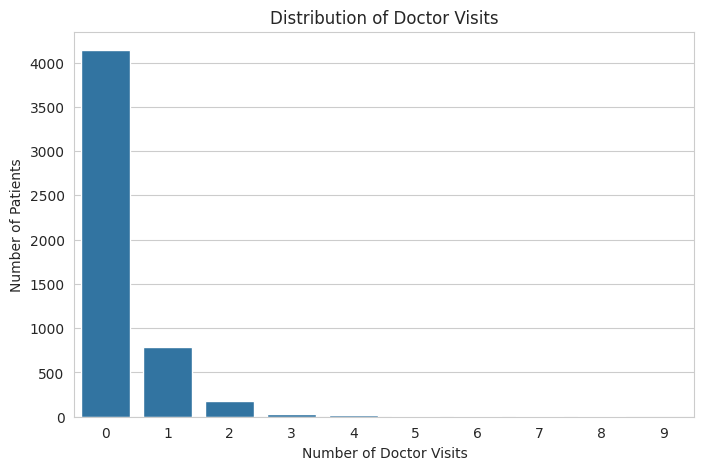

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="visits")

plt.title("Distribution of Doctor Visits")
plt.xlabel("Number of Doctor Visits")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
gender_visits = df.groupby("gender")["visits"].mean().reset_index()

print(gender_visits)

   gender    visits
0  female  0.361954
1    male  0.236334


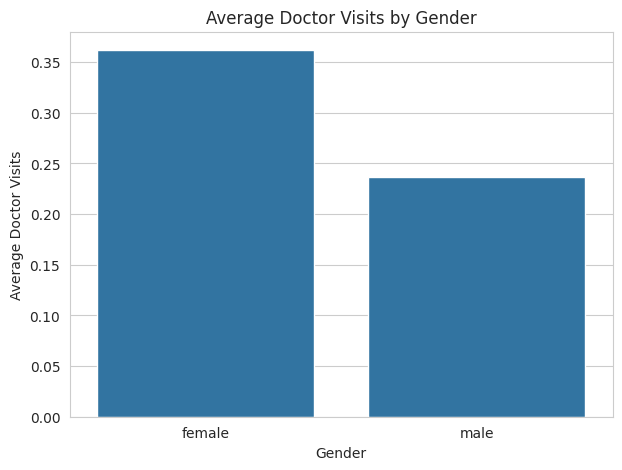

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(data=gender_visits, x="gender", y="visits")

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Doctor Visits")

plt.show()

In [ ]:
illness_visits = df.groupby("illness")["visits"].mean().reset_index()

print(illness_visits)

   illness    visits
0        0  0.078507
1        1  0.295482
2        2  0.403805
3        3  0.420664
4        4  0.576642
5        5  0.813559


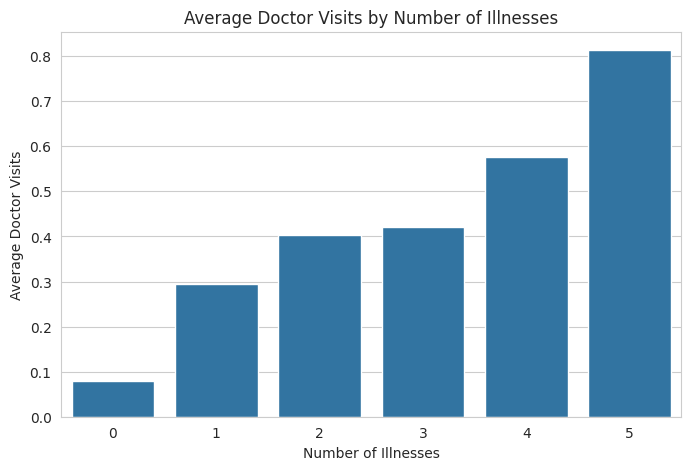

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(data=illness_visits, x="illness", y="visits")

plt.title("Average Doctor Visits by Number of Illnesses")
plt.xlabel("Number of Illnesses")
plt.ylabel("Average Doctor Visits")

plt.show()

In [ ]:
health_visits = df.groupby("health")["visits"].mean().reset_index()

print(health_visits)

    health    visits
0        0  0.199273
1        1  0.335358
2        2  0.381166
3        3  0.417582
4        4  0.534759
5        5  0.530303
6        6  0.625000
7        7  0.918033
8        8  0.476190
9        9  0.656250
10      10  1.523810
11      11  0.833333
12      12  1.000000


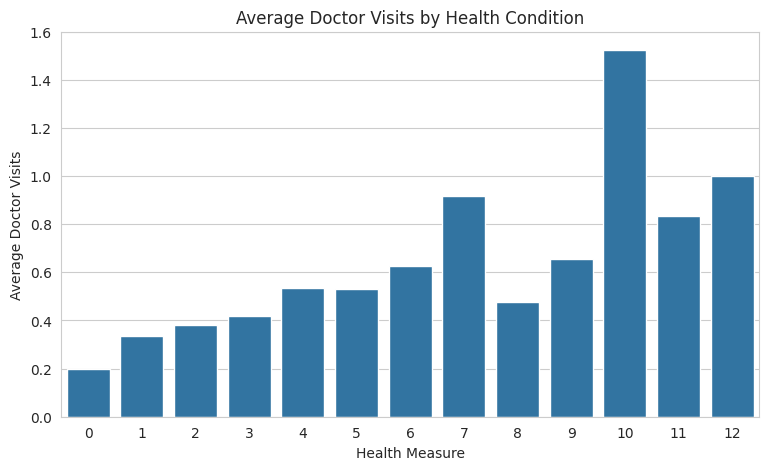

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(data=health_visits, x="health", y="visits")

plt.title("Average Doctor Visits by Health Condition")
plt.xlabel("Health Measure")
plt.ylabel("Average Doctor Visits")

plt.show()

In [ ]:
reduced_visits = df.groupby("reduced")["visits"].mean().reset_index()

print(reduced_visits)

    reduced    visits
0         0  0.183880
1         1  0.355932
2         2  0.574074
3         3  1.094595
4         4  0.800000
5         5  1.275000
6         6  1.176471
7         7  1.184211
8         8  1.176471
9         9  1.714286
10       10  2.000000
11       11  5.000000
12       12  2.000000
13       13  4.000000
14       14  1.547872


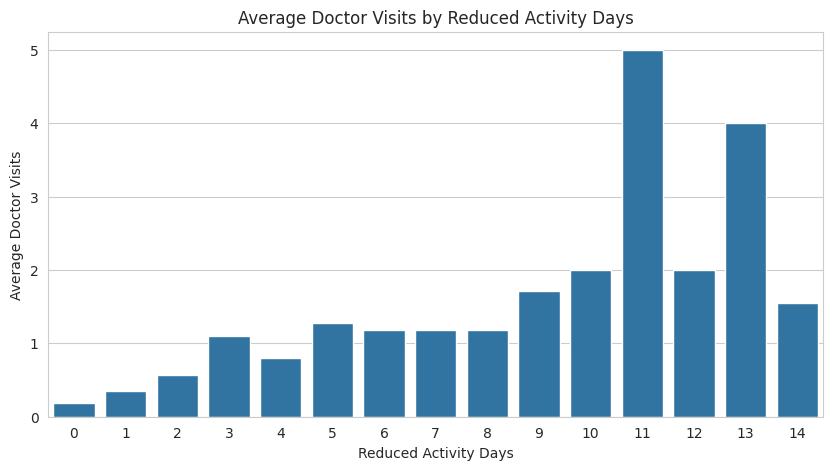

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(data=reduced_visits, x="reduced", y="visits")

plt.title("Average Doctor Visits by Reduced Activity Days")
plt.xlabel("Reduced Activity Days")
plt.ylabel("Average Doctor Visits")

plt.show()

In [ ]:
for col in ["nchronic", "lchronic"]:
    result = df.groupby(col)["visits"].mean().reset_index()
    print("\n", col)
    print(result)


 nchronic
  nchronic    visits
0       no  0.272111
1      yes  0.345602

 lchronic
  lchronic    visits
0       no  0.261941
1      yes  0.603306


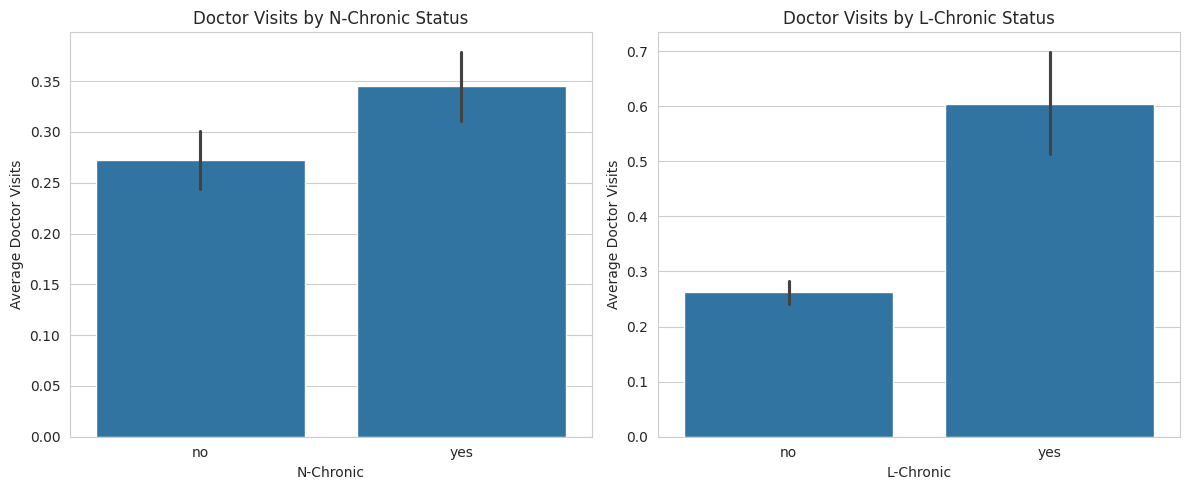

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(data=df, x="nchronic", y="visits", ax=axes[0])
axes[0].set_title("Doctor Visits by N-Chronic Status")
axes[0].set_xlabel("N-Chronic")
axes[0].set_ylabel("Average Doctor Visits")

sns.barplot(data=df, x="lchronic", y="visits", ax=axes[1])
axes[1].set_title("Doctor Visits by L-Chronic Status")
axes[1].set_xlabel("L-Chronic")
axes[1].set_ylabel("Average Doctor Visits")

plt.tight_layout()
plt.show()

In [ ]:
insurance_columns = ["private", "freepoor", "freerepat"]

for col in insurance_columns:
    result = df.groupby(col)["visits"].mean().reset_index()
    print("\n", col)
    print(result)


 private
  private    visits
0      no  0.307400
1     yes  0.294604

 freepoor
  freepoor    visits
0       no  0.308172
1      yes  0.157658

 freerepat
  freerepat    visits
0        no  0.257868
1       yes  0.466544


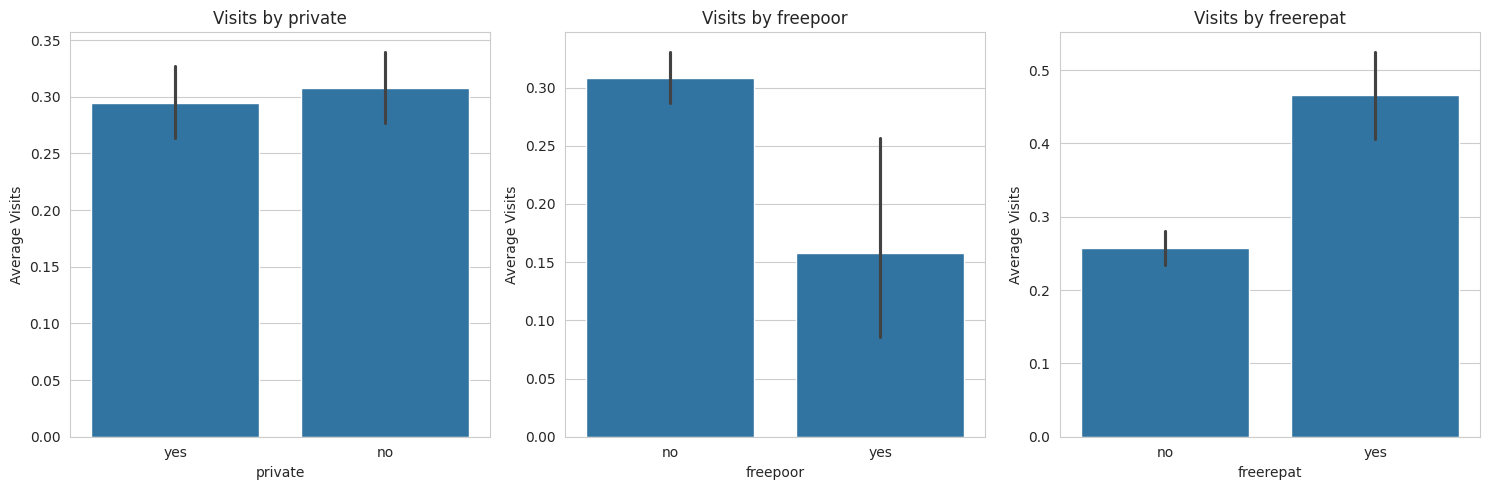

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, insurance_columns):
    sns.barplot(data=df, x=col, y="visits", ax=ax)
    ax.set_title(f"Visits by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Average Visits")

plt.tight_layout()
plt.show()

In [ ]:
income_visits = df.groupby("income")["visits"].mean().reset_index()

print(income_visits)

    income    visits
0     0.00  0.367089
1     0.01  0.485714
2     0.06  0.200000
3     0.15  0.349398
4     0.25  0.420921
5     0.35  0.359307
6     0.45  0.305000
7     0.55  0.252677
8     0.65  0.246154
9     0.75  0.244898
10    0.90  0.207131
11    1.10  0.177285
12    1.30  0.277778
13    1.50  0.265116


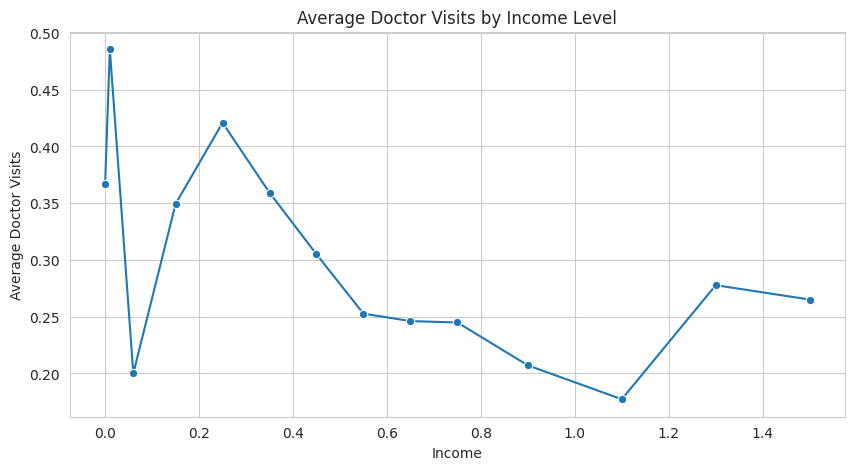

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(data=income_visits, x="income", y="visits", marker="o")

plt.title("Average Doctor Visits by Income Level")
plt.xlabel("Income")
plt.ylabel("Average Doctor Visits")

plt.show()

In [ ]:
age_visits = df.groupby("age")["visits"].mean().reset_index()

print(age_visits)

     age    visits
0   0.19  0.212766
1   0.22  0.201154
2   0.27  0.258126
3   0.32  0.242525
4   0.37  0.246575
5   0.42  0.317460
6   0.47  0.270718
7   0.52  0.414414
8   0.57  0.399267
9   0.62  0.354430
10  0.67  0.377778
11  0.72  0.482968


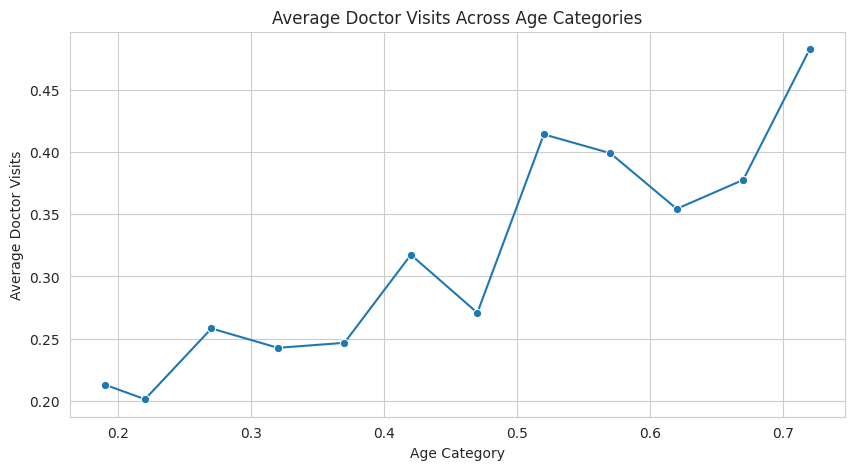

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(data=age_visits, x="age", y="visits", marker="o")

plt.title("Average Doctor Visits Across Age Categories")
plt.xlabel("Age Category")
plt.ylabel("Average Doctor Visits")

plt.show()

In [ ]:
numeric_columns = [
    "visits",
    "age",
    "income",
    "illness",
    "reduced",
    "health"
]

correlation = df[numeric_columns].corr()

display(correlation)

,visits,age,income,illness,reduced,health
visits,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


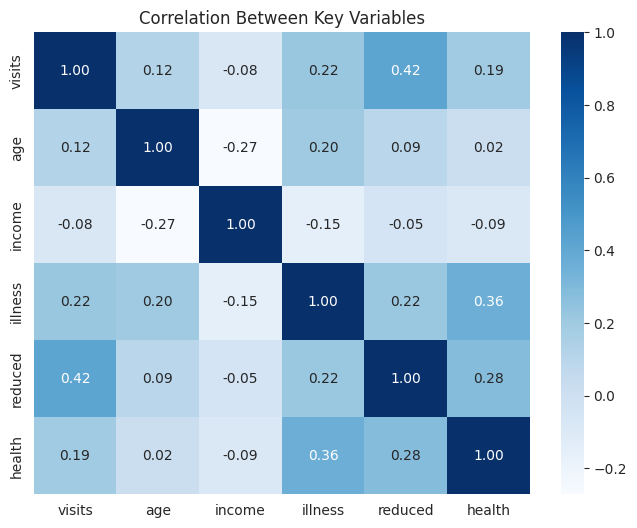

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Key Variables")

plt.show()

In [ ]:
visit_correlation = correlation["visits"].sort_values(ascending=False)

print("Correlation with Doctor Visits:")
print(visit_correlation)

Correlation with Doctor Visits:
visits     1.000000
reduced    0.418954
illness    0.223552
health     0.193272
age        0.124537
income    -0.076840
Name: visits, dtype: float64


In [ ]:
summary = pd.DataFrame({
    "Factor": [
        "Gender - Female",
        "Gender - Male",
        "Illness",
        "Reduced Activity",
        "Health",
        "L-Chronic - Yes",
        "L-Chronic - No",
        "Freerepat - Yes",
        "Freerepat - No"
    ],
    "Observation": [
        df[df["gender"] == "female"]["visits"].mean(),
        df[df["gender"] == "male"]["visits"].mean(),
        df.groupby("illness")["visits"].mean().max(),
        df.groupby("reduced")["visits"].mean().max(),
        df.groupby("health")["visits"].mean().max(),
        df[df["lchronic"] == "yes"]["visits"].mean(),
        df[df["lchronic"] == "no"]["visits"].mean(),
        df[df["freerepat"] == "yes"]["visits"].mean(),
        df[df["freerepat"] == "no"]["visits"].mean()
    ]
})

display(summary)

,Factor,Observation
0,Gender - Female,0.361954
1,Gender - Male,0.236334
2,Illness,0.813559
3,Reduced Activity,5.000000
4,Health,1.523810
5,L-Chronic - Yes,0.603306
6,L-Chronic - No,0.261941
7,Freerepat - Yes,0.466544
8,Freerepat - No,0.257868


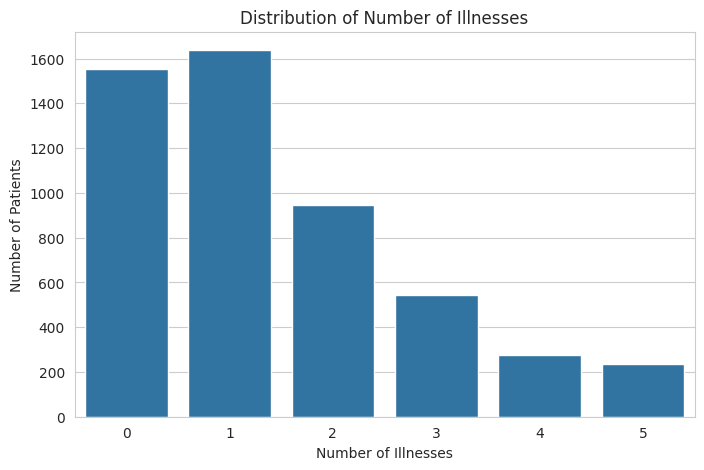

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="illness")

plt.title("Distribution of Number of Illnesses")
plt.xlabel("Number of Illnesses")
plt.ylabel("Number of Patients")

plt.show()

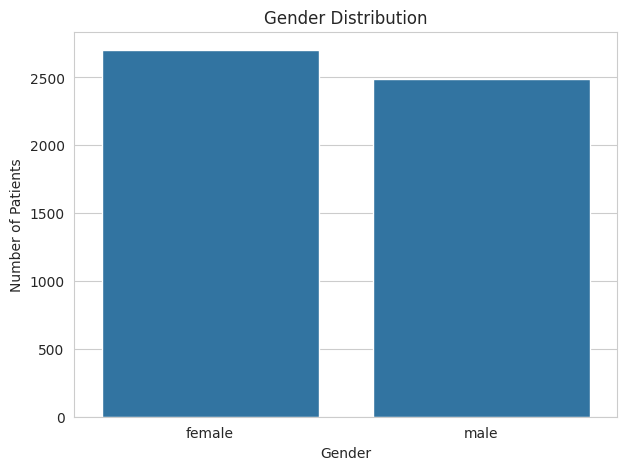

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

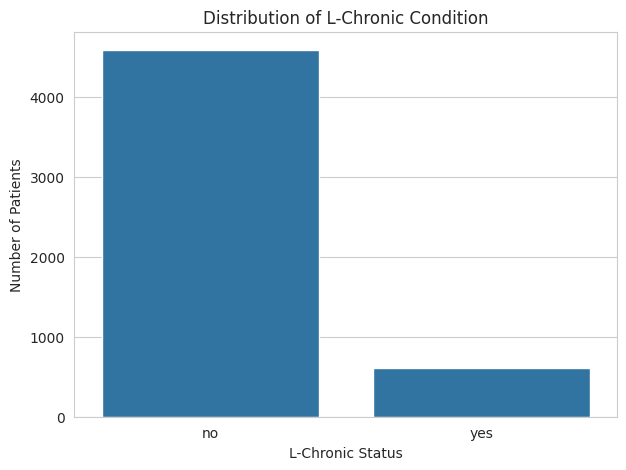

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="lchronic")

plt.title("Distribution of L-Chronic Condition")
plt.xlabel("L-Chronic Status")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
## Key Findings
##1. Most respondents recorded zero doctor visits, while one or two visits were considerably more common than higher visit counts.

##2. Female respondents recorded a higher average number of doctor visits than male respondents.

##3. Average doctor visits generally increased as the number of reported illnesses increased.

##4. Higher levels of reduced activity due to illness were associated with higher average doctor visits.

##5. Respondents with the recorded L-chronic condition had a higher average number of doctor visits than those without it.

##6. Doctor visit patterns varied across the recorded health and insurance/access categories.

##7. The correlation analysis showed that illness, reduced activity and health-related measures had stronger positive associations with doctor visits than income.